# Project 9 — Pandas Analyzer & Data Visualization

Sales Data Analysis using Pandas, NumPy, Matplotlib and Seaborn.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class SalesDataAnalyzer:

    def __init__(self):
        self.data = pd.DataFrame()
        self.last_plot = None
        self.last_plot_name = "sales_visualization.png"

    def __del__(self):
        pass

    def load_data(self, file_path):
        self.data = pd.read_csv(file_path)
        print("\nDataset loaded successfully.")
        print("Shape:", self.data.shape)

    def explore_data(self):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        print("\n--- Dataset Information ---")
        print(self.data.head())
        print("\nColumns:")
        print(list(self.data.columns))
        print("\nShape:", self.data.shape)
        print("\nData Types:")
        print(self.data.dtypes)
        print("\nMissing Values:")
        print(self.data.isnull().sum())

    def clean_data(self):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        print("\nMissing values before cleaning:")
        print(self.data.isnull().sum())

        numeric_columns = self.data.select_dtypes(include=np.number).columns
        for column in numeric_columns:
            self.data[column] = self.data[column].fillna(self.data[column].median())

        categorical_columns = self.data.select_dtypes(exclude=np.number).columns
        for column in categorical_columns:
            if self.data[column].isnull().any():
                self.data[column] = self.data[column].fillna(self.data[column].mode()[0])

        print("\nMissing values after cleaning:")
        print(self.data.isnull().sum())

    def mathematical_operations(self):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        print("\n--- Mathematical Operations ---")

        if "Sales" in self.data.columns:
            self.data["Sales_With_Tax"] = self.data["Sales"] * 1.18
            print(self.data[["Sales", "Sales_With_Tax"]].head())

        if "Sales" in self.data.columns and "Units" in self.data.columns:
            self.data["Sales_Per_Unit"] = self.data["Sales"] / self.data["Units"]
            print("\nSales per Unit:")
            print(self.data[["Sales", "Units", "Sales_Per_Unit"]].head())

        print("\nNumPy array from Sales column:")
        print(self.data["Sales"].to_numpy()[:10])

    def combine_data(self, other_dataframe):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        combined = pd.concat([self.data, other_dataframe], ignore_index=True)
        print("\nCombined DataFrame:")
        print(combined.head())
        print("Combined Shape:", combined.shape)

    def split_data(self):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        if "Region" in self.data.columns:
            region = input("Enter region to split: ")
            result = self.data[self.data["Region"].str.lower() == region.lower()]
            print("\nSplit Data:")
            print(result)
        elif "Product" in self.data.columns:
            product = input("Enter product to split: ")
            result = self.data[self.data["Product"].str.lower() == product.lower()]
            print("\nSplit Data:")
            print(result)

    def search_sort_filter(self):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        print("\n--- Search, Sort and Filter ---")

        if "Product" in self.data.columns:
            product = input("Enter product to search: ")
            result = self.data[
                self.data["Product"].str.contains(product, case=False, na=False)
            ]
            print("\nSearch Result:")
            print(result)

        print("\nTop 10 Sales:")
        print(self.data.sort_values("Sales", ascending=False).head(10))

        print("\nSales greater than average:")
        print(self.data[self.data["Sales"] > self.data["Sales"].mean()])

    def aggregate_functions(self):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        print("\n--- Aggregate Functions ---")

        print("Total Sales:", self.data["Sales"].sum())
        print("Average Sales:", self.data["Sales"].mean())
        print("Sales Count:", self.data["Sales"].count())

        if "Region" in self.data.columns:
            print("\nSales by Region:")
            print(self.data.groupby("Region")["Sales"].agg(["sum", "mean", "count"]))

        if "Product" in self.data.columns:
            print("\nSales by Product:")
            print(self.data.groupby("Product")["Sales"].agg(["sum", "mean", "count"]))

    def statistical_analysis(self):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        print("\n--- Statistical Analysis ---")

        print("\nDescribe:")
        print(self.data.describe())

        print("\nStandard Deviation:")
        print(self.data["Sales"].std())

        print("\nVariance:")
        print(self.data["Sales"].var())

        print("\n25th Percentile:")
        print(self.data["Sales"].quantile(0.25))

        print("\n50th Percentile:")
        print(self.data["Sales"].quantile(0.50))

        print("\n75th Percentile:")
        print(self.data["Sales"].quantile(0.75))

    def create_pivot_table(self):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        if "Region" in self.data.columns and "Product" in self.data.columns:
            pivot = pd.pivot_table(
                self.data,
                values="Sales",
                index="Region",
                columns="Product",
                aggfunc="sum",
                fill_value=0
            )

            print("\n--- Pivot Table ---")
            print(pivot)

            print("\n--- GroupBy ---")
            print(self.data.groupby("Region")["Sales"].sum())

            print("\n--- Transform ---")
            self.data["Region_Total"] = self.data.groupby("Region")["Sales"].transform("sum")
            print(self.data[["Region", "Sales", "Region_Total"]].head())

    def visualize_data(self):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        product_sales = self.data.groupby("Product")["Sales"].sum()
        product_sales.plot(kind="bar", ax=axes[0, 0])
        axes[0, 0].set_title("Sales by Product")
        axes[0, 0].set_xlabel("Product")
        axes[0, 0].set_ylabel("Sales")
        axes[0, 0].tick_params(axis="x", rotation=45)

        monthly_sales = self.data.copy()
        monthly_sales["Date"] = pd.to_datetime(monthly_sales["Date"])
        monthly_sales = monthly_sales.groupby(
            monthly_sales["Date"].dt.to_period("M")
        )["Sales"].sum()

        monthly_sales.plot(kind="line", marker="o", ax=axes[0, 1])
        axes[0, 1].set_title("Monthly Sales Trend")
        axes[0, 1].set_xlabel("Month")
        axes[0, 1].set_ylabel("Sales")

        axes[1, 0].scatter(self.data["Units"], self.data["Sales"])
        axes[1, 0].set_title("Sales vs Units")
        axes[1, 0].set_xlabel("Units")
        axes[1, 0].set_ylabel("Sales")

        region_sales = self.data.groupby("Region")["Sales"].sum()
        axes[1, 1].pie(
            region_sales,
            labels=region_sales.index,
            autopct="%1.1f%%"
        )
        axes[1, 1].set_title("Sales by Region")

        plt.tight_layout()

        self.last_plot = fig
        self.last_plot_name = "sales_dashboard.png"

        plt.show()

    def create_extra_visualizations(self):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        plt.figure(figsize=(8, 5))
        plt.hist(self.data["Sales"], bins=10)
        plt.title("Sales Distribution")
        plt.xlabel("Sales")
        plt.ylabel("Frequency")
        plt.savefig("sales_histogram.png")
        plt.show()

        plt.figure(figsize=(8, 5))
        sns.boxplot(x="Product", y="Sales", data=self.data)
        plt.title("Sales by Product Box Plot")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig("sales_boxplot.png")
        plt.show()

        plt.figure(figsize=(8, 5))
        correlation = self.data.select_dtypes(include=np.number).corr()
        sns.heatmap(correlation, annot=True, cmap="coolwarm")
        plt.title("Sales Correlation Heatmap")
        plt.tight_layout()
        plt.savefig("sales_heatmap.png")
        plt.show()

    def save_visualization(self):
        if self.last_plot is None:
            print("\nPlease create a visualization first.")
            return

        filename = input(
            "Enter filename with extension (.png, .jpg or .jpeg): "
        )

        self.last_plot.savefig(filename)
        print("\nVisualization saved successfully:", filename)

    def export_data(self):
        if self.data.empty:
            print("\nPlease load the dataset first.")
            return

        self.data.to_csv("cleaned_sales_data.csv", index=False)
        print("\nCleaned data exported successfully.")

    def show_menu(self):
        while True:
            print("\n========================================")
            print("   PROJECT 9 - PANDAS SALES ANALYZER")
            print("========================================")
            print("1. Load Dataset")
            print("2. Explore Data")
            print("3. Perform DataFrame Operations")
            print("4. Handle Missing Data")
            print("5. Generate Descriptive Statistics")
            print("6. Data Visualization")
            print("7. Save Visualization")
            print("8. Exit")

            choice = input("\nEnter your choice: ")

            if choice == "1":
                self.load_data("sales_data.csv")

            elif choice == "2":
                self.explore_data()

            elif choice == "3":
                print("\n--- DataFrame Operations ---")
                print("1. Mathematical Operations")
                print("2. Combine Data")
                print("3. Split Data")
                print("4. Search, Sort and Filter")
                print("5. Aggregate Functions")
                print("6. Pivot Table / GroupBy / Transform")

                operation = input("Enter operation: ")

                if operation == "1":
                    self.mathematical_operations()

                elif operation == "2":
                    other = self.data.head(5).copy()
                    self.combine_data(other)

                elif operation == "3":
                    self.split_data()

                elif operation == "4":
                    self.search_sort_filter()

                elif operation == "5":
                    self.aggregate_functions()

                elif operation == "6":
                    self.create_pivot_table()

                else:
                    print("Invalid operation.")

            elif choice == "4":
                self.clean_data()

            elif choice == "5":
                self.statistical_analysis()

            elif choice == "6":
                self.visualize_data()
                self.create_extra_visualizations()

            elif choice == "7":
                self.save_visualization()

            elif choice == "8":
                print("\nThank you for using Sales Data Analyzer.")
                break

            else:
                print("\nInvalid choice. Please try again.")


analyzer = SalesDataAnalyzer()

## Run the Menu

The next cell starts the required menu-driven interface.

In [7]:
analyzer = SalesDataAnalyzer()
analyzer.load_data("sales_data.csv")


Dataset loaded successfully.
Shape: (100, 8)


In [8]:
analyzer.explore_data()


--- Dataset Information ---
   SalesID        Date   Product Region  Sales   Profit  Units  Year
0        1  2025-01-05    Laptop  North  85000  12000.0      5  2025
1        2  2025-01-08    Mobile   West  45000   7000.0     10  2025
2        3  2025-01-12    Tablet  South  30000   4500.0      8  2025
3        4  2025-01-15   Monitor   East  22000   3500.0      6  2025
4        5  2025-01-20  Keyboard  North   8000   1500.0     20  2025

Columns:
['SalesID', 'Date', 'Product', 'Region', 'Sales', 'Profit', 'Units', 'Year']

Shape: (100, 8)

Data Types:
SalesID      int64
Date           str
Product        str
Region         str
Sales        int64
Profit     float64
Units        int64
Year         int64
dtype: object

Missing Values:
SalesID    0
Date       0
Product    0
Region     1
Sales      0
Profit     1
Units      0
Year       0
dtype: int64


In [9]:
analyzer.mathematical_operations()


--- Mathematical Operations ---
   Sales  Sales_With_Tax
0  85000        100300.0
1  45000         53100.0
2  30000         35400.0
3  22000         25960.0
4   8000          9440.0

Sales per Unit:
   Sales  Units  Sales_Per_Unit
0  85000      5    17000.000000
1  45000     10     4500.000000
2  30000      8     3750.000000
3  22000      6     3666.666667
4   8000     20      400.000000

NumPy array from Sales column:
[85000 45000 30000 22000  8000  5000 90000 50000 28000 24000]


In [10]:
other_data = analyzer.data.head(5).copy()
analyzer.combine_data(other_data)


Combined DataFrame:
   SalesID        Date   Product Region  Sales   Profit  Units  Year  \
0        1  2025-01-05    Laptop  North  85000  12000.0      5  2025   
1        2  2025-01-08    Mobile   West  45000   7000.0     10  2025   
2        3  2025-01-12    Tablet  South  30000   4500.0      8  2025   
3        4  2025-01-15   Monitor   East  22000   3500.0      6  2025   
4        5  2025-01-20  Keyboard  North   8000   1500.0     20  2025   

   Sales_With_Tax  Sales_Per_Unit  
0        100300.0    17000.000000  
1         53100.0     4500.000000  
2         35400.0     3750.000000  
3         25960.0     3666.666667  
4          9440.0      400.000000  
Combined Shape: (105, 10)


In [11]:
analyzer.split_data()

Enter region to split:  North



Split Data:
    SalesID        Date   Product Region   Sales   Profit  Units  Year  \
0         1  2025-01-05    Laptop  North   85000  12000.0      5  2025   
4         5  2025-01-20  Keyboard  North    8000   1500.0     20  2025   
8         9  2025-02-11    Tablet  North   28000   4200.0      7  2025   
12       13  2025-03-04    Laptop  North   95000  14000.0      6  2025   
16       17  2025-03-23  Keyboard  North    8500   1600.0     21  2025   
19       20  2025-04-07    Mobile  North   52000   8200.0     12  2025   
23       24  2025-04-27     Mouse  North    5800   1050.0     28  2025   
27       28  2025-05-18   Monitor  North   27000   4300.0      8  2025   
30       31  2025-06-04    Laptop  North  102000  15000.0      7  2025   
34       35  2025-06-24  Keyboard  North   10500   2000.0     26  2025   
38       39  2025-07-13    Tablet  North   36000   5300.0     10  2025   
42       43  2025-08-03    Laptop  North  105000  15500.0      7  2025   
46       47  2025-08-23  

In [12]:
analyzer.search_sort_filter()


--- Search, Sort and Filter ---


Enter product to search:  Laptop



Search Result:
    SalesID        Date Product Region   Sales   Profit  Units  Year  \
0         1  2025-01-05  Laptop  North   85000  12000.0      5  2025   
6         7  2025-02-03  Laptop  South   90000      NaN      6  2025   
12       13  2025-03-04  Laptop  North   95000  14000.0      6  2025   
18       19  2025-04-02  Laptop   West   88000  13000.0      5  2025   
24       25  2025-05-03  Laptop  South   98000  14500.0      6  2025   
30       31  2025-06-04  Laptop  North  102000  15000.0      7  2025   
36       37  2025-07-03  Laptop  South   99000  14600.0      6  2025   
42       43  2025-08-03  Laptop  North  105000  15500.0      7  2025   
48       49  2025-09-03  Laptop  South  110000  16200.0      7  2025   
54       55  2025-10-03  Laptop  North  108000  15900.0      7  2025   
60       61  2025-11-03  Laptop  South  112000  16500.0      7  2025   
66       67  2025-12-03  Laptop  North  115000  17000.0      8  2025   
72       73  2026-01-03  Laptop  South  118000  

In [13]:
analyzer.aggregate_functions()


--- Aggregate Functions ---
Total Sales: 4461600
Average Sales: 44616.0
Sales Count: 100

Sales by Region:
            sum          mean  count
Region                              
East     879000  36625.000000     24
North   1338300  51473.076923     26
South   1279200  53300.000000     24
West     933100  37324.000000     25

Sales by Product:
              sum           mean  count
Product                                
Keyboard   188000   11750.000000     16
Laptop    1820000  107058.823529     17
Mobile    1052000   61882.352941     17
Monitor    591000   34764.705882     17
Mouse      115600    7225.000000     16
Tablet     695000   40882.352941     17


In [14]:
analyzer.create_pivot_table()


--- Pivot Table ---
Product  Keyboard  Laptop  Mobile  Monitor  Mouse  Tablet
Region                                                   
East        10000       0  512000   277000  45000   35000
North       94500  855000   52000    27000   5800  304000
South       74000  877000       0    23000  12200  293000
West         9500   88000  488000   264000  52600   31000

--- GroupBy ---
Region
East      879000
North    1338300
South    1279200
West      933100
Name: Sales, dtype: int64

--- Transform ---
  Region  Sales  Region_Total
0  North  85000     1338300.0
1   West  45000      933100.0
2  South  30000     1279200.0
3   East  22000      879000.0
4  North   8000     1338300.0


In [15]:
analyzer.clean_data()


Missing values before cleaning:
SalesID           0
Date              0
Product           0
Region            1
Sales             0
Profit            1
Units             0
Year              0
Sales_With_Tax    0
Sales_Per_Unit    0
Region_Total      1
dtype: int64

Missing values after cleaning:
SalesID           0
Date              0
Product           0
Region            0
Sales             0
Profit            0
Units             0
Year              0
Sales_With_Tax    0
Sales_Per_Unit    0
Region_Total      0
dtype: int64


In [16]:
analyzer.statistical_analysis()


--- Statistical Analysis ---

Describe:
          SalesID          Sales        Profit       Units         Year  \
count  100.000000     100.000000    100.000000  100.000000   100.000000   
mean    50.500000   44616.000000   6792.000000   17.220000  2025.280000   
std     29.011492   34836.520718   5020.180084   10.609296     0.451261   
min      1.000000    5000.000000    900.000000    5.000000  2025.000000   
25%     25.750000   12375.000000   2375.000000    9.000000  2025.000000   
50%     50.500000   38000.000000   5700.000000   13.000000  2025.000000   
75%     75.250000   62500.000000   9475.000000   26.250000  2026.000000   
max    100.000000  128000.000000  19000.000000   42.000000  2026.000000   

       Sales_With_Tax  Sales_Per_Unit  Region_Total  
count      100.000000      100.000000  1.000000e+02  
mean     52646.880000     4678.875686  1.111993e+06  
std      41107.094448     5165.534037  2.043335e+05  
min       5900.000000      200.000000  8.790000e+05  
25%      1460

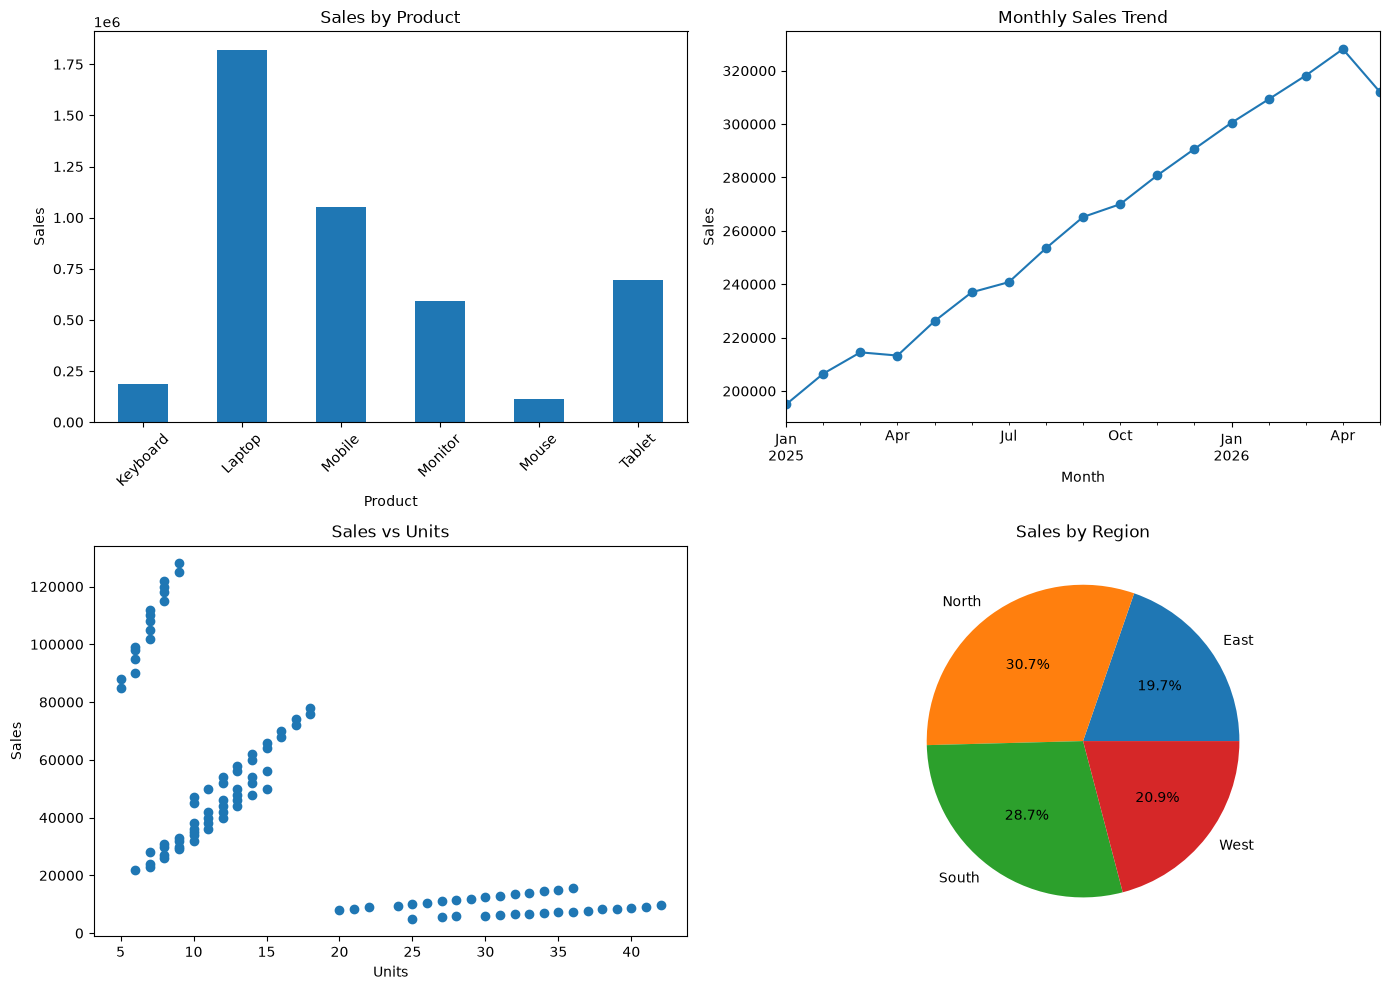

In [17]:
analyzer.visualize_data()

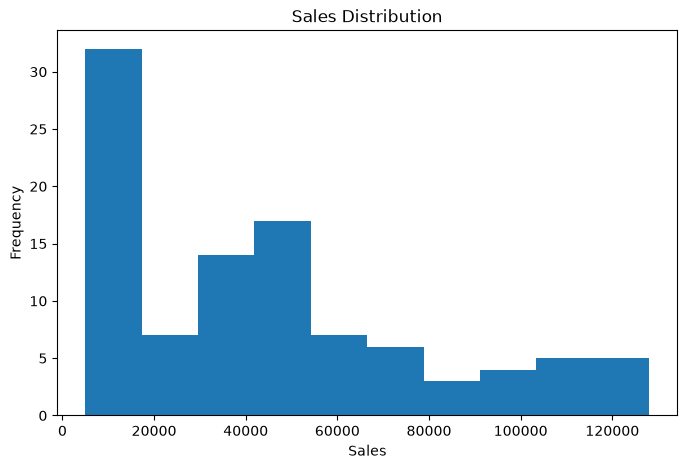

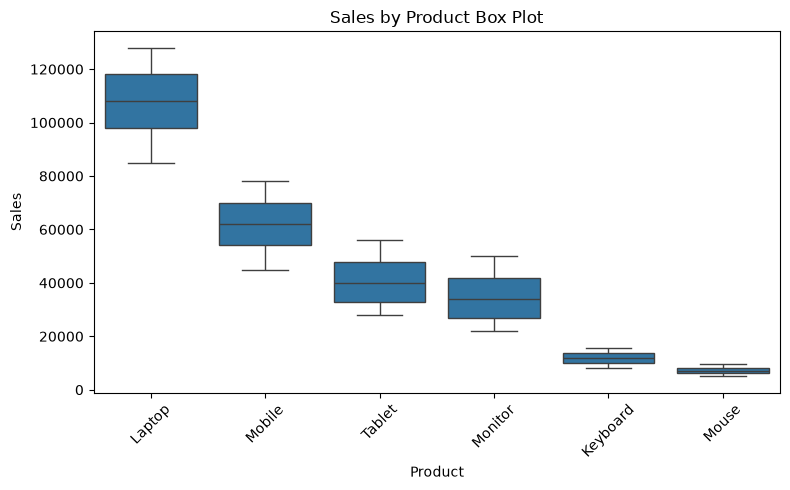

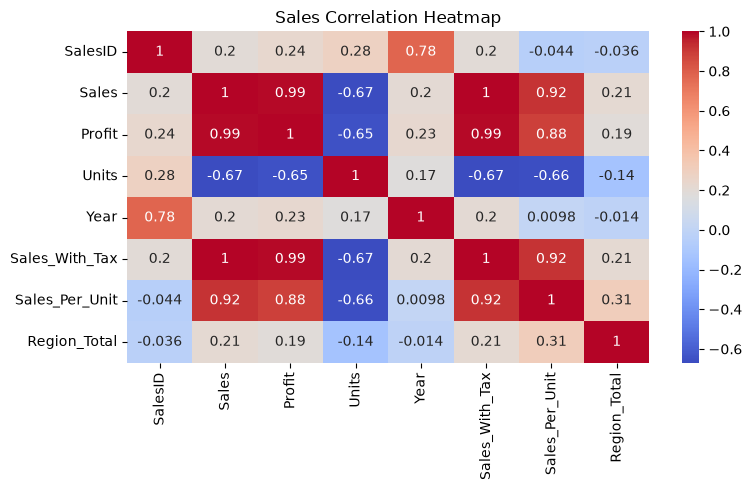

In [18]:
analyzer.create_extra_visualizations()

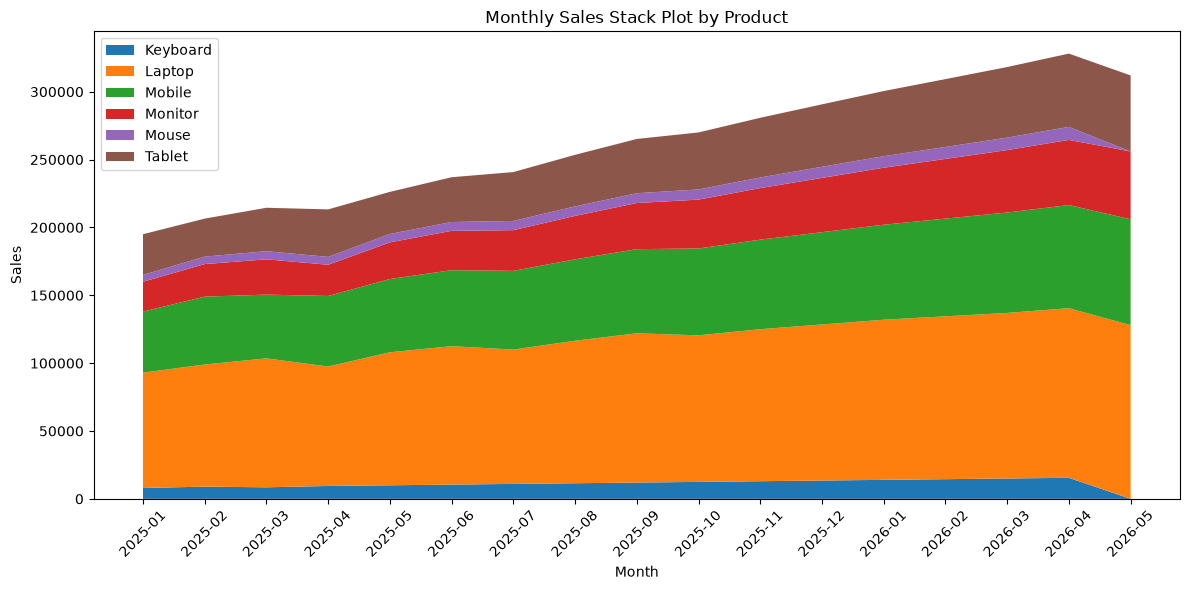

In [19]:
plot_data = analyzer.data.copy()

plot_data["Date"] = pd.to_datetime(plot_data["Date"])
plot_data["Month"] = plot_data["Date"].dt.to_period("M").astype(str)

monthly_product_sales = plot_data.pivot_table(
    index="Month",
    columns="Product",
    values="Sales",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(12, 6))

plt.stackplot(
    monthly_product_sales.index,
    *[monthly_product_sales[col].values for col in monthly_product_sales.columns],
    labels=monthly_product_sales.columns
)

plt.title("Monthly Sales Stack Plot by Product")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("sales_stackplot.png")
plt.show()

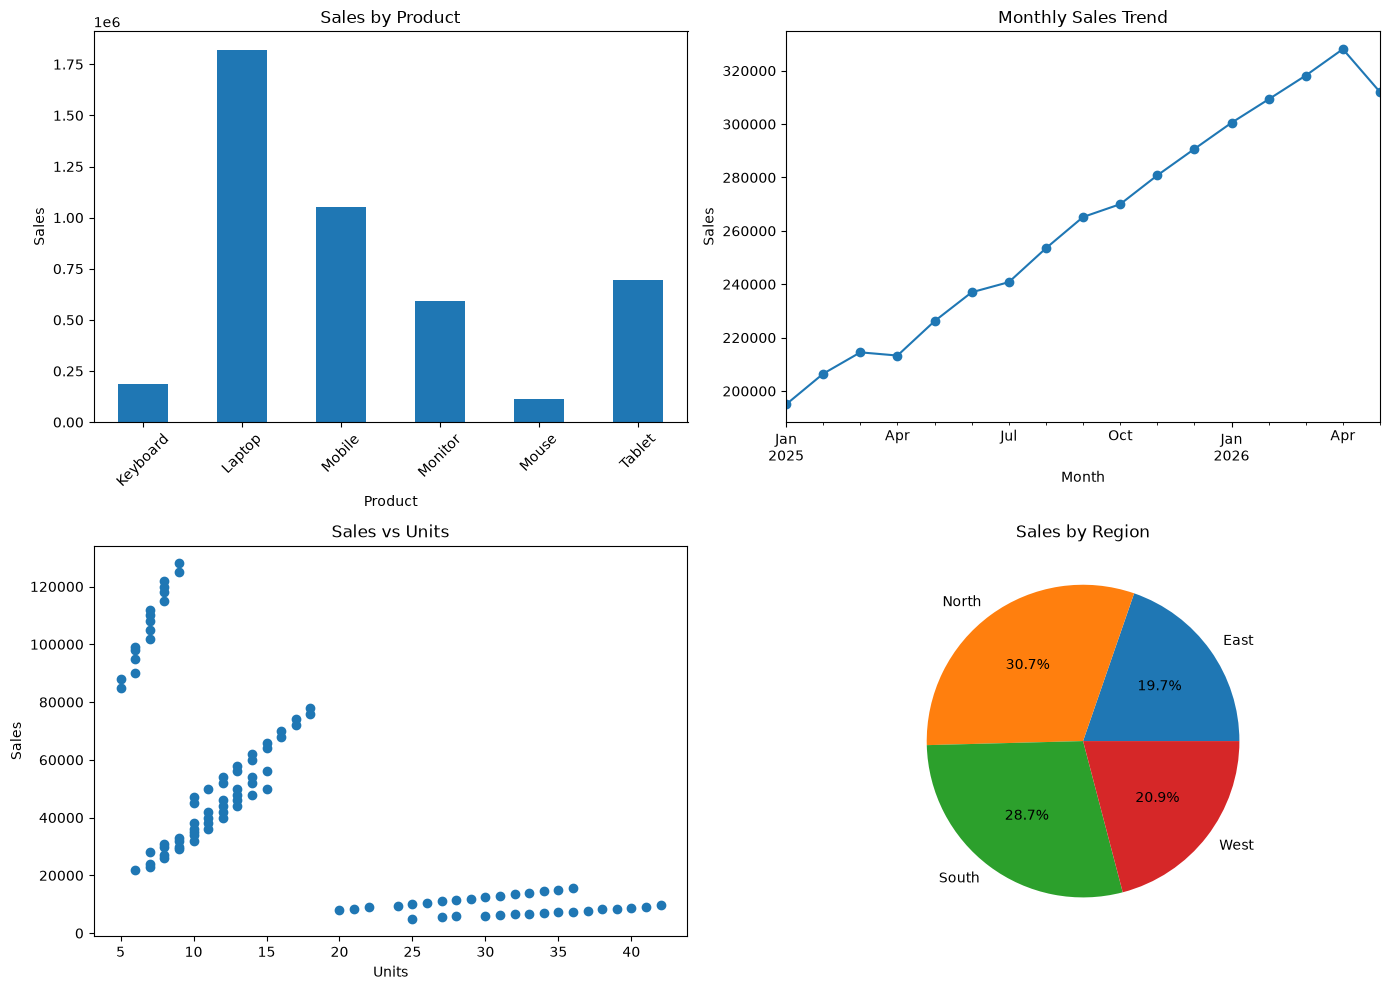

In [20]:
analyzer.visualize_data()

In [21]:
analyzer.save_visualization()

Enter filename with extension (.png, .jpg or .jpeg):  final_sales_dashboard.png



Visualization saved successfully: final_sales_dashboard.png


In [22]:
analyzer.show_menu()


   PROJECT 9 - PANDAS SALES ANALYZER
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit



Enter your choice:  1



Dataset loaded successfully.
Shape: (100, 8)

   PROJECT 9 - PANDAS SALES ANALYZER
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit



Enter your choice:  2



--- Dataset Information ---
   SalesID        Date   Product Region  Sales   Profit  Units  Year
0        1  2025-01-05    Laptop  North  85000  12000.0      5  2025
1        2  2025-01-08    Mobile   West  45000   7000.0     10  2025
2        3  2025-01-12    Tablet  South  30000   4500.0      8  2025
3        4  2025-01-15   Monitor   East  22000   3500.0      6  2025
4        5  2025-01-20  Keyboard  North   8000   1500.0     20  2025

Columns:
['SalesID', 'Date', 'Product', 'Region', 'Sales', 'Profit', 'Units', 'Year']

Shape: (100, 8)

Data Types:
SalesID      int64
Date           str
Product        str
Region         str
Sales        int64
Profit     float64
Units        int64
Year         int64
dtype: object

Missing Values:
SalesID    0
Date       0
Product    0
Region     1
Sales      0
Profit     1
Units      0
Year       0
dtype: int64

   PROJECT 9 - PANDAS SALES ANALYZER
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Des


Enter your choice:  8



Thank you for using Sales Data Analyzer.
